# 04 · Weather Data

**Input :** `data/processed/panel_daily.parquet` (station coordinates)  
**Outputs:** `data/processed/weather_hourly.parquet` · `data/processed/weather_daily.parquet`

Steps:
0. Imports & setup
1. Load AWV station coordinates
2. Set up Open-Meteo API client
3. Define weather variables
4. Fetch hourly weather for all stations (cached)
5. Add derived weather variables
6. Save hourly weather panel
7. Build daily weather aggregates
8. Sanity check plots
9. Final summary

## 0. Imports & Setup

In [19]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "openmeteo-requests", "requests-cache", "retry-requests"])

from pathlib import Path
import time

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
RAW_WX    = ROOT / "data" / "raw" / "weather"
FIGS      = ROOT / "outputs" / "figures"
RAW_WX.mkdir(parents=True, exist_ok=True)

SEASON_MAP = {
    12: "winter",  1: "winter",  2: "winter",
     3: "spring",  4: "spring",  5: "spring",
     6: "summer",  7: "summer",  8: "summer",
     9: "autumn", 10: "autumn", 11: "autumn",
}

URL        = "https://archive-api.open-meteo.com/v1/archive"
START_DATE = "2023-01-01"
END_DATE   = "2025-12-31"

## 1. Load AWV Station Coordinates

In [20]:
panel_daily = pd.read_parquet(
    PROCESSED / "panel_daily.parquet",
    columns=["site ID", "naam", "lat", "long"],
)

site_locations = (
    panel_daily[["site ID", "naam", "lat", "long"]]
    .drop_duplicates("site ID")
    .dropna(subset=["lat", "long"])
    .reset_index(drop=True)
)

print(f"Unique stations        : {len(site_locations)}")
print(f"Lat range              : {site_locations['lat'].min():.4f} – {site_locations['lat'].max():.4f}")
print(f"Lon range              : {site_locations['long'].min():.4f} – {site_locations['long'].max():.4f}")
site_locations.head(5)

Unique stations        : 150
Lat range              : 50.7513 – 51.3575
Lon range              : 2.7429 – 5.7973


,site ID,naam,lat,long
0,1,Machelen,50.916183,4.456122
1,2,Brasschaat 2,51.275120,4.471690
2,3,Brasschaat 1,51.275030,4.472220
3,4,Balen 1,51.160230,5.190110
4,5,Balen 2,51.160180,5.190030


## 2. Set Up Open-Meteo API Client

In [21]:
cache_session = requests_cache.CachedSession(
    str(RAW_WX / ".cache"), expire_after=-1   # never expire
)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

print("API client ready (disk cache + auto-retry).")

API client ready (disk cache + auto-retry).


## 3. Define Weather Variables

In [22]:
VARIABLES = [
    "temperature_2m",        # °C
    "precipitation",         # mm / hour
    "wind_speed_10m",        # km/h
    "relative_humidity_2m",  # %
    "sunshine_duration",     # seconds per hour
    "wind_gusts_10m",        # km/h  (extreme weather flagging)
    "rain",                  # mm (rain only, no snow)
    "snowfall",              # cm
    "weather_code",          # WMO code
]

print(f"Variables : {VARIABLES}")
print(f"Period    : {START_DATE} → {END_DATE}")
print(f"Stations  : {len(site_locations)}")

Variables : ['temperature_2m', 'precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'sunshine_duration', 'wind_gusts_10m', 'rain', 'snowfall', 'weather_code']
Period    : 2023-01-01 → 2025-12-31
Stations  : 150


## 4. Fetch Weather Data for All Stations

Each station is fetched individually from the Open-Meteo archive API.  
The `requests_cache` layer writes responses to disk so re-runs are instant.

In [23]:
from openmeteo_requests import OpenMeteoRequestsError

CHECKPOINT = RAW_WX / "weather_checkpoint.parquet"
WEATHER_HOURLY = PROCESSED / "weather_hourly.parquet"

# Prefer the saved hourly weather panel if it already exists.
# The checkpoint is only for resuming an interrupted API fetch.
if WEATHER_HOURLY.exists():
    done = pd.read_parquet(WEATHER_HOURLY)
    fetched_ids = set(done["site ID"].unique())
    all_weather = [done]
    print(f"Loaded existing {WEATHER_HOURLY.name}: {done.shape}")
elif CHECKPOINT.exists():
    done = pd.read_parquet(CHECKPOINT)
    fetched_ids = set(done["site ID"].unique())
    all_weather = [done]
    print(f"Resuming: {len(fetched_ids)} stations already fetched.")
else:
    fetched_ids = set()
    all_weather = []

remaining = site_locations[~site_locations["site ID"].isin(fetched_ids)]
print(f"Stations to fetch: {len(remaining)}")

for _, row in remaining.iterrows():
    params = {
        "latitude":   row["lat"],
        "longitude":  row["long"],
        "start_date": START_DATE,
        "end_date":   END_DATE,
        "hourly":     VARIABLES,
        "timezone":   "Europe/Brussels",
    }

    for attempt in range(10):
        try:
            response = openmeteo.weather_api(URL, params=params)[0]
            break
        except OpenMeteoRequestsError as e:
            if "limit exceeded" in str(e).lower():
                print(f"  Rate limited, waiting 90s (attempt {attempt+1}/10)...")
                time.sleep(90)
            else:
                raise
    else:
        raise RuntimeError(f"Failed after 10 attempts for site {row['site ID']}")

    hourly = response.Hourly()

    t_start = (
        pd.to_datetime(hourly.Time(), unit="s", utc=True)
        .tz_convert("Europe/Brussels")
        .replace(tzinfo=None)
    )
    t_end = (
        pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True)
        .tz_convert("Europe/Brussels")
        .replace(tzinfo=None)
    )
    freq = pd.Timedelta(seconds=hourly.Interval())

    df = pd.DataFrame({
        "site ID":              row["site ID"],
        "datetime":             pd.date_range(start=t_start, end=t_end,
                                              freq=freq, inclusive="left"),
        "temperature_2m":       hourly.Variables(0).ValuesAsNumpy(),
        "precipitation":        hourly.Variables(1).ValuesAsNumpy(),
        "wind_speed_10m":       hourly.Variables(2).ValuesAsNumpy(),
        "relative_humidity_2m": hourly.Variables(3).ValuesAsNumpy(),
        "sunshine_duration":    hourly.Variables(4).ValuesAsNumpy(),
        "wind_gusts_10m":       hourly.Variables(5).ValuesAsNumpy(),
        "rain":                 hourly.Variables(6).ValuesAsNumpy(),
        "snowfall":             hourly.Variables(7).ValuesAsNumpy(),
        "weather_code":         hourly.Variables(8).ValuesAsNumpy(),
    })

    all_weather.append(df)

    # Save checkpoint every 10 stations
    n_total = len(fetched_ids) + len([x for x in all_weather if x["site ID"].iloc[0] not in fetched_ids])
    if len(all_weather) % 10 == 0:
        pd.concat(all_weather, ignore_index=True).to_parquet(CHECKPOINT, index=False)
        print(f"  Checkpoint saved at {len(all_weather)} new stations")

    n = len(fetched_ids) + len(all_weather)
    if n % 10 == 0 or n == len(site_locations):
        print(f"  Fetched {n}/{len(site_locations)} stations")

    time.sleep(8)

weather_raw = pd.concat(all_weather, ignore_index=True)

# Clean up checkpoint after successful completion
if CHECKPOINT.exists():
    CHECKPOINT.unlink()

print(f"\nRaw weather data shape: {weather_raw.shape}")
weather_raw.head(3)

Loaded existing weather_hourly.parquet: (3945450, 20)
Stations to fetch: 0

Raw weather data shape: (3945450, 20)


,site ID,datetime,temperature_2m,precipitation,wind_speed_10m,relative_humidity_2m,sunshine_duration,wind_gusts_10m,rain,snowfall,weather_code,is_raining,rain_category,temp_category,wind_category,sunshine_min,hour,is_peak_morning,is_peak_evening,date
0,1,2023-01-01 00:00:00,15.20,0.0,31.178993,51.262646,0.0,55.079998,0.0,0.0,3.0,False,none,mild,moderate,0.0,0,False,False,2023-01-01
1,1,2023-01-01 01:00:00,14.95,0.0,33.342297,48.922974,0.0,55.079998,0.0,0.0,3.0,False,none,cool,moderate,0.0,1,False,False,2023-01-01
2,1,2023-01-01 02:00:00,14.35,0.1,31.062386,53.587059,0.0,60.120003,0.1,0.0,51.0,True,light,cool,moderate,0.0,2,False,False,2023-01-01


## 5. Add Derived Weather Variables

In [24]:
weather_raw["is_raining"] = weather_raw["precipitation"] > 0.1

# based on https://en.wikipedia.org/wiki/Rain#Intensity
weather_raw["rain_category"] = pd.cut(
    weather_raw["precipitation"],
    bins=[-0.01, 0.1, 2.5, 7.6, float("inf")],
    labels=["none", "light", "moderate", "heavy"]
)

# no standard universal temperature categorization
# bassed on expert judgment and typical Belgian weather patterns
weather_raw["temp_category"] = pd.cut(
    weather_raw["temperature_2m"],
    bins=[-float("inf"), 0, 5, 10, 15, 20, 25, float("inf")],
    labels=["freezing", "very_cold", "cold", "cool", "mild", "warm", "hot"],
)

# based on Beaufort scale (https://en.wikipedia.org/wiki/Beaufort_scale), converted to km/h
weather_raw["wind_category"] = pd.cut(
    weather_raw["wind_speed_10m"],
    bins=[-0.01, 6, 20, 38, float("inf")],
    labels=["calm", "light", "moderate", "strong"]
)

weather_raw["sunshine_min"]    = weather_raw["sunshine_duration"] / 60
weather_raw["hour"]            = weather_raw["datetime"].dt.hour
weather_raw["is_peak_morning"] = weather_raw["hour"].isin([7, 8, 9])
weather_raw["is_peak_evening"] = weather_raw["hour"].isin([16, 17, 18])

# midnight timestamp (datetime64[ns]) — matches panel_daily["date"] dtype
weather_raw["date"] = weather_raw["datetime"].dt.normalize()

# Keep weather data aligned with the cycling study window before saving.
# Open-Meteo timestamps can create a one-hour local-time boundary row
# after UTC → Europe/Brussels conversion.
study_start = pd.Timestamp(START_DATE)
study_end   = pd.Timestamp(END_DATE) + pd.Timedelta(hours=23)
rows_before = len(weather_raw)
weather_raw = weather_raw[
    weather_raw["datetime"].between(study_start, study_end)
].copy()
rows_removed = rows_before - len(weather_raw)

print("Derived columns added. Sample dtypes:")
print(weather_raw[["rain_category", "temp_category", "wind_category",
                    "sunshine_min", "is_peak_morning", "date"]].dtypes)
print(f"Filtered to study window: {study_start} → {study_end} ({rows_removed:,} rows removed)")

Derived columns added. Sample dtypes:
rain_category            category
temp_category            category
wind_category            category
sunshine_min              float32
is_peak_morning              bool
date               datetime64[ns]
dtype: object
Filtered to study window: 2023-01-01 00:00:00 → 2025-12-31 23:00:00 (0 rows removed)


## 6. Build Daily Weather Aggregates

In [25]:
# ── base daily aggregation ────────────────────────────────────────────────────
daily_weather = (
    weather_raw.groupby(["site ID", "date"], as_index=False).agg(
        temp_avg    =("temperature_2m",       "mean"),
        temp_max    =("temperature_2m",       "max"),
        temp_min    =("temperature_2m",       "min"),
        precip_total=("precipitation",        "sum"),
        wind_avg    =("wind_speed_10m",       "mean"),
        wind_max    =("wind_gusts_10m",       "max"),
        humidity_avg=("relative_humidity_2m", "mean"),
        sunshine_min=("sunshine_min",         "sum"),
        rain_hours  =("is_raining",           "sum"),
    )
)

# ── commute-period aggregates ─────────────────────────────────────────────────
morn = (
    weather_raw[weather_raw["is_peak_morning"]]
    .groupby(["site ID", "date"], as_index=False)
    .agg(precip_morning=("precipitation",  "sum"),
         wind_morning  =("wind_speed_10m", "mean"))
)

eve = (
    weather_raw[weather_raw["is_peak_evening"]]
    .groupby(["site ID", "date"], as_index=False)
    .agg(precip_evening=("precipitation",  "sum"),
         wind_evening  =("wind_speed_10m", "mean"))
)

daily_weather = (
    daily_weather
    .merge(morn, on=["site ID", "date"], how="left")
    .merge(eve,  on=["site ID", "date"], how="left")
)

# ── bad weather flags ─────────────────────────────────────────────────────────
daily_weather["is_rainy_day"]   = daily_weather["precip_total"] > 1.0
daily_weather["is_cold_day"]    = daily_weather["temp_avg"]     < 5.0
daily_weather["is_windy_day"]   = daily_weather["wind_avg"]     > 30.0
daily_weather["is_bad_weather"] = (
    daily_weather["is_rainy_day"] |
    daily_weather["is_cold_day"]  |
    daily_weather["is_windy_day"]
)

out_d = PROCESSED / "weather_daily.parquet"
daily_weather.to_parquet(out_d, index=False)

print(f"Saved : {out_d.name}")
print(f"Shape : {daily_weather.shape}")
print(f"\nSample (3 rows):")
display(daily_weather[["site ID", "date", "temp_avg", "precip_total",
                        "wind_avg", "sunshine_min", "is_bad_weather"]].head(3))

Saved : weather_daily.parquet
Shape : (164400, 19)

Sample (3 rows):


,site ID,date,temp_avg,precip_total,wind_avg,sunshine_min,is_bad_weather
0,1,2023-01-01,13.075000,4.4,24.928438,60.463188,True
1,1,2023-01-02,9.916667,4.6,20.658726,74.589767,True
2,1,2023-01-03,6.866667,0.6,19.998777,160.281006,False


## 7. Sanity Check Plots

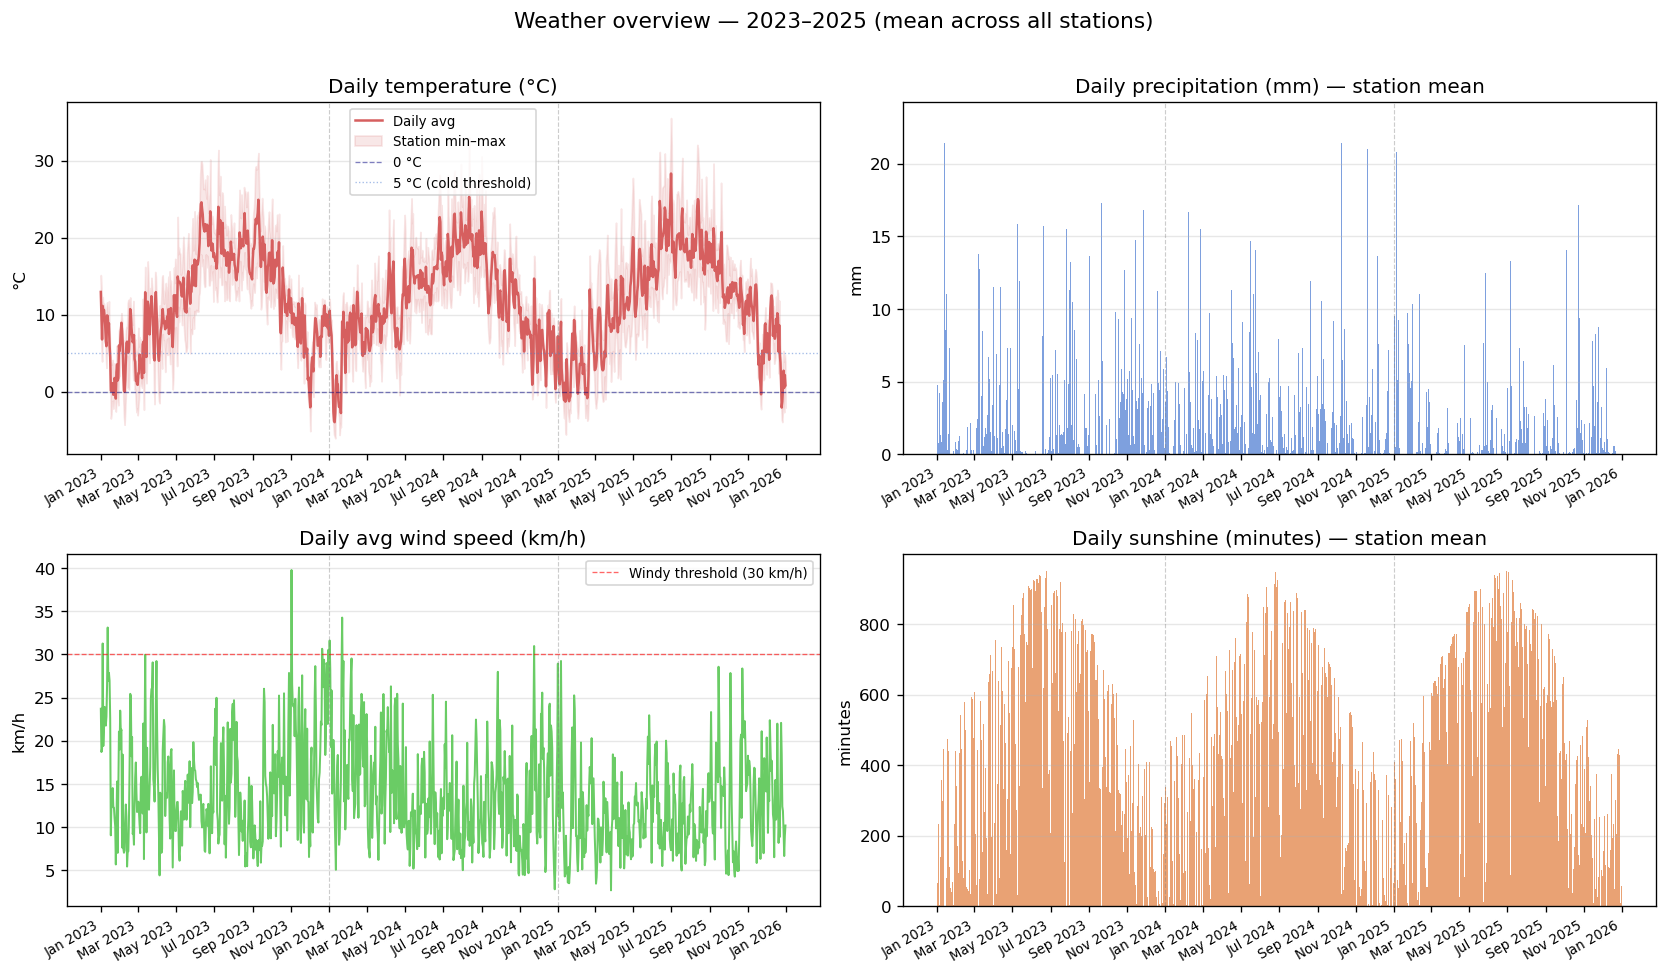

04_weather_overview.png saved.


In [26]:
# ── cross-station daily means for overview ────────────────────────────────────
wx_cross = (
    daily_weather.groupby("date", as_index=False).agg(
        temp_avg    =("temp_avg",     "mean"),
        temp_max    =("temp_max",     "mean"),
        temp_min    =("temp_min",     "mean"),
        precip_total=("precip_total", "mean"),
        wind_avg    =("wind_avg",     "mean"),
        sunshine_min=("sunshine_min", "mean"),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# temperature
ax = axes[0, 0]
ax.plot(wx_cross["date"], wx_cross["temp_avg"],
        color="#d65f5f", lw=1.5, label="Daily avg")
ax.fill_between(wx_cross["date"], wx_cross["temp_min"], wx_cross["temp_max"],
                color="#d65f5f", alpha=0.15, label="Station min–max")
ax.axhline(0, color="navy",   lw=0.8, ls="--", alpha=0.5, label="0 °C")
ax.axhline(5, color="#4878d0", lw=0.8, ls=":",  alpha=0.5, label="5 °C (cold threshold)")
ax.set_title("Daily temperature (°C)")
ax.set_ylabel("°C")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# precipitation
ax = axes[0, 1]
ax.bar(wx_cross["date"], wx_cross["precip_total"],
       width=1, color="#4878d0", alpha=0.7)
ax.set_title("Daily precipitation (mm) — station mean")
ax.set_ylabel("mm")
ax.grid(axis="y", alpha=0.3)

# wind speed
ax = axes[1, 0]
ax.plot(wx_cross["date"], wx_cross["wind_avg"],
        color="#6acc65", lw=1.2)
ax.axhline(30, color="red", lw=0.8, ls="--", alpha=0.6, label="Windy threshold (30 km/h)")
ax.set_title("Daily avg wind speed (km/h)")
ax.set_ylabel("km/h")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# sunshine
ax = axes[1, 1]
ax.bar(wx_cross["date"], wx_cross["sunshine_min"],
       width=1, color="#e07b39", alpha=0.7)
ax.set_title("Daily sunshine (minutes) — station mean")
ax.set_ylabel("minutes")
ax.grid(axis="y", alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    for yr in ["2024-01-01", "2025-01-01"]:
        ax.axvline(pd.Timestamp(yr), color="grey", lw=0.7, ls="--", alpha=0.4)

fig.suptitle("Weather overview — 2023–2025 (mean across all stations)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGS / "04_weather_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("04_weather_overview.png saved.")

Rainy hours (>0.1 mm): 769,837  (19.5% of all hours)


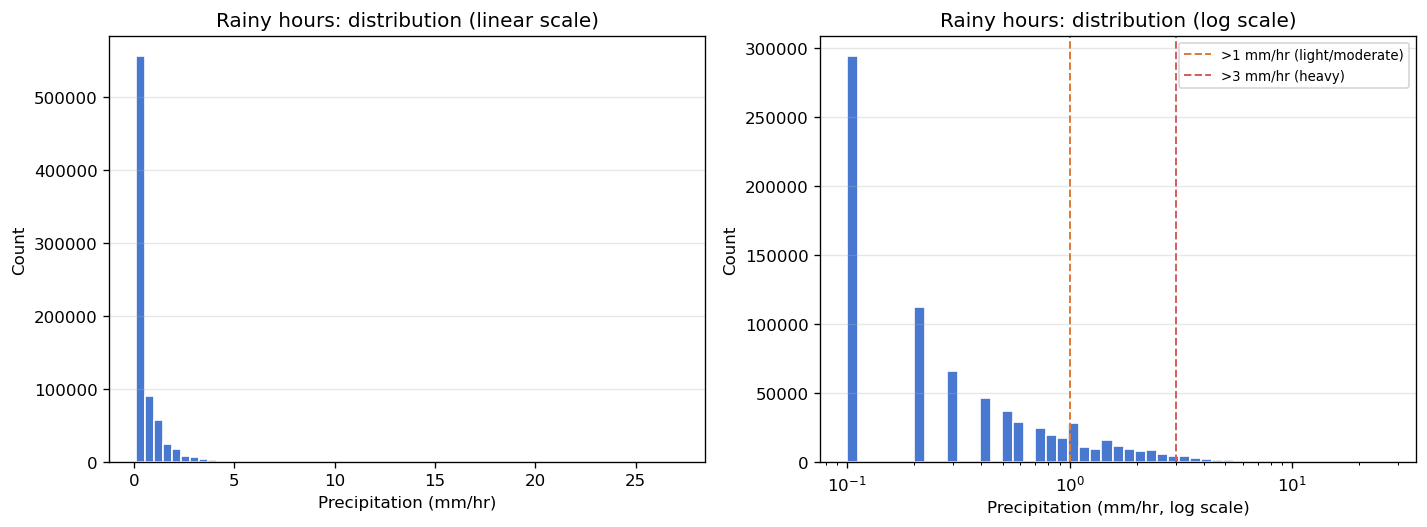

04_rain_distribution.png saved.


In [27]:
# ── rain distribution ─────────────────────────────────────────────────────────
rainy = weather_raw.loc[weather_raw["precipitation"] > 0.1, "precipitation"]
print(f"Rainy hours (>0.1 mm): {len(rainy):,}  ({len(rainy)/len(weather_raw)*100:.1f}% of all hours)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# linear
axes[0].hist(rainy, bins=60, color="#4878d0", edgecolor="white", lw=0.3)
axes[0].set_xlabel("Precipitation (mm/hr)")
axes[0].set_ylabel("Count")
axes[0].set_title("Rainy hours: distribution (linear scale)")
axes[0].grid(axis="y", alpha=0.3)

# log x-axis
log_bins = np.logspace(np.log10(0.1), np.log10(float(rainy.max()) + 0.1), 50)
axes[1].hist(rainy, bins=log_bins, color="#4878d0", edgecolor="white", lw=0.3)
axes[1].set_xscale("log")
axes[1].set_xlabel("Precipitation (mm/hr, log scale)")
axes[1].set_ylabel("Count")
axes[1].set_title("Rainy hours: distribution (log scale)")
for thresh, label, col in [(1.0, "light/moderate", "#e07b39"),
                            (3.0, "heavy",          "#d65f5f")]:
    axes[1].axvline(thresh, color=col, lw=1.2, ls="--",
                    label=f">{thresh:.0f} mm/hr ({label})")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGS / "04_rain_distribution.png", dpi=150)
plt.show()
print("04_rain_distribution.png saved.")

## 8. Final Summary

In [28]:
pct_bad  = daily_weather["is_bad_weather"].mean() * 100
pct_rain = daily_weather["is_rainy_day"].mean()   * 100
pct_cold = daily_weather["is_cold_day"].mean()    * 100
pct_wind = daily_weather["is_windy_day"].mean()   * 100

daily_weather["season"] = daily_weather["date"].dt.month.map(SEASON_MAP)
season_temp = (
    daily_weather.groupby("season")["temp_avg"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

print("=" * 52)
print("WEATHER DATA SUMMARY")
print("=" * 52)
print(f"weather_hourly : {weather_raw.shape[0]:>10,} rows × {weather_raw.shape[1]} cols")
print(f"weather_daily  : {daily_weather.shape[0]:>10,} rows × {daily_weather.shape[1]} cols")
print(f"Date range     : {daily_weather['date'].min().date()} → {daily_weather['date'].max().date()}")
print(f"Stations       : {daily_weather['site ID'].nunique()}")
print()
print(f"Bad weather station-days (any flag) : {pct_bad:.1f}%")
print(f"  of which  rainy (>1 mm)           : {pct_rain:.1f}%")
print(f"            cold  (<5 °C)           : {pct_cold:.1f}%")
print(f"            windy (>30 km/h)        : {pct_wind:.1f}%")
print()
print("Average temperature by season:")
for s, t in season_temp.items():
    print(f"  {s:<8} : {t:>5.1f} °C")
print()
sz_h = (PROCESSED / "weather_hourly.parquet").stat().st_size / 1_048_576
sz_d = (PROCESSED / "weather_daily.parquet").stat().st_size  / 1_048_576
print(f"weather_hourly.parquet : {sz_h:.1f} MB")
print(f"weather_daily.parquet  : {sz_d:.1f} MB")
print()
print("Both parquet files saved successfully.")

WEATHER DATA SUMMARY
weather_hourly :  3,945,450 rows × 20 cols
weather_daily  :    164,400 rows × 20 cols
Date range     : 2023-01-01 → 2025-12-31
Stations       : 150

Bad weather station-days (any flag) : 51.9%
  of which  rainy (>1 mm)           : 40.8%
            cold  (<5 °C)           : 14.6%
            windy (>30 km/h)        : 1.1%

Average temperature by season:
  summer   :  18.6 °C
  autumn   :  12.4 °C
  spring   :  10.8 °C
  winter   :   5.3 °C

weather_hourly.parquet : 44.8 MB
weather_daily.parquet  : 3.9 MB

Both parquet files saved successfully.


Open-Meteo hourly timestamps are converted to Europe/Brussels time before aggregation. This conversion can create a one-hour boundary row just outside the study period, so `weather_raw` is explicitly filtered to `2023-01-01 00:00` → `2025-12-31 23:00` before saving. This keeps `weather_hourly.parquet` and `weather_daily.parquet` aligned with the cycling panel date range.